In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

sys.path.append(str(Path.cwd().parent))
from src.config import DATA_RAW, DATA_PROC
from src.preprocessing import process_experiment

sns.set_theme(style="darkgrid")

In [2]:
def load_ims_experiment(exp_path: Path, n_channels: int) -> dict:
    files = sorted([f for f in exp_path.iterdir() if f.is_file()])
    
    if n_channels == 8:
        col_names = [f"b{b}_ch{c}" for b in range(1, 5) for c in range(1, 3)]
    else:
        col_names = [f"b{b}_ch1" for b in range(1, 5)]
    
    bearing_data = {f"bearing_{i}": [] for i in range(1, 5)}
    
    for f in tqdm(files, desc=f"Cargando {exp_path.name}"):
        df = pd.read_csv(f, sep="\t", header=None, names=col_names)
        for b_idx in range(1, 5):
            if n_channels == 8:
                cols = [f"b{b_idx}_ch1", f"b{b_idx}_ch2"]
            else:
                cols = [f"b{b_idx}_ch1"]
            bearing_data[f"bearing_{b_idx}"].append(df[cols].values)
    
    return bearing_data

experiments_meta = {
    "exp1": {"path": DATA_RAW / "1st_test", "n_channels": 8},
    "exp2": {"path": DATA_RAW / "2nd_test", "n_channels": 4},
    "exp3": {"path": DATA_RAW / "3rd_test", "n_channels": 4},
}

experiments = {}
for exp_name, meta in experiments_meta.items():
    print(f"Cargando {exp_name}...")
    experiments[exp_name] = load_ims_experiment(meta["path"], meta["n_channels"])

Cargando exp1...


Cargando 1st_test:   0%|          | 0/2156 [00:00<?, ?it/s]

Cargando exp2...


Cargando 2nd_test:   0%|          | 0/984 [00:00<?, ?it/s]

Cargando exp3...


Cargando 3rd_test:   0%|          | 0/6324 [00:00<?, ?it/s]

In [3]:
DATA_PROC.mkdir(parents=True, exist_ok=True)

all_dfs = []
for exp_name, bearing_data in experiments.items():
    print(f"\nProcesando {exp_name}...")
    df = process_experiment(bearing_data, exp_name=exp_name, top_n=5)
    
    # Guardar CSV individual por experimento
    out_path = DATA_PROC / f"{exp_name}_features.csv"
    df.to_csv(out_path, index=False)
    print(f"  → Guardado: {out_path} | Shape: {df.shape}")
    
    all_dfs.append(df)

# Dataset unificado con los 3 experimentos
df_all = pd.concat(all_dfs, ignore_index=True)
df_all.to_csv(DATA_PROC / "all_features.csv", index=False)
print(f"\nDataset completo guardado | Shape: {df_all.shape}")
print(df_all.head())


Procesando exp1...


exp1 - bearing_4: 100%|██████████| 2156/2156 [00:31<00:00, 68.59it/s]


  → Guardado: /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/processed/exp1_features.csv | Shape: (8624, 18)

Procesando exp2...


exp2 - bearing_4: 100%|██████████| 984/984 [00:15<00:00, 64.35it/s]


  → Guardado: /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/processed/exp2_features.csv | Shape: (3936, 18)

Procesando exp3...


exp3 - bearing_4: 100%|██████████| 6324/6324 [01:37<00:00, 64.54it/s]


  → Guardado: /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/processed/exp3_features.csv | Shape: (25296, 18)

Dataset completo guardado | Shape: (37856, 18)
  experiment    bearing  snapshot       rms  kurtosis  skewness  peak_to_peak  \
0       exp1  bearing_1         0  0.124614  1.069163 -0.029993         1.108   
1       exp1  bearing_1         1  0.123811  1.161552 -0.070075         1.042   
2       exp1  bearing_1         2  0.125246  0.986286 -0.041646         0.940   
3       exp1  bearing_1         3  0.125197  1.034294  0.005162         1.055   
4       exp1  bearing_1         4  0.125618  1.110164 -0.060196         1.011   

   crest_factor  fft_freq_1  fft_amp_1  fft_freq_2  fft_amp_2  fft_freq_3  \
0      5.777850         0.0   0.094593      1010.0   0.027736      1017.0   
1      5.282236         0.0   0.094903      1010.0   0.029017       505.0   
2      4.974196         0.0   0.096187      1010.0   0.029570       505.0   
3      4.776455        

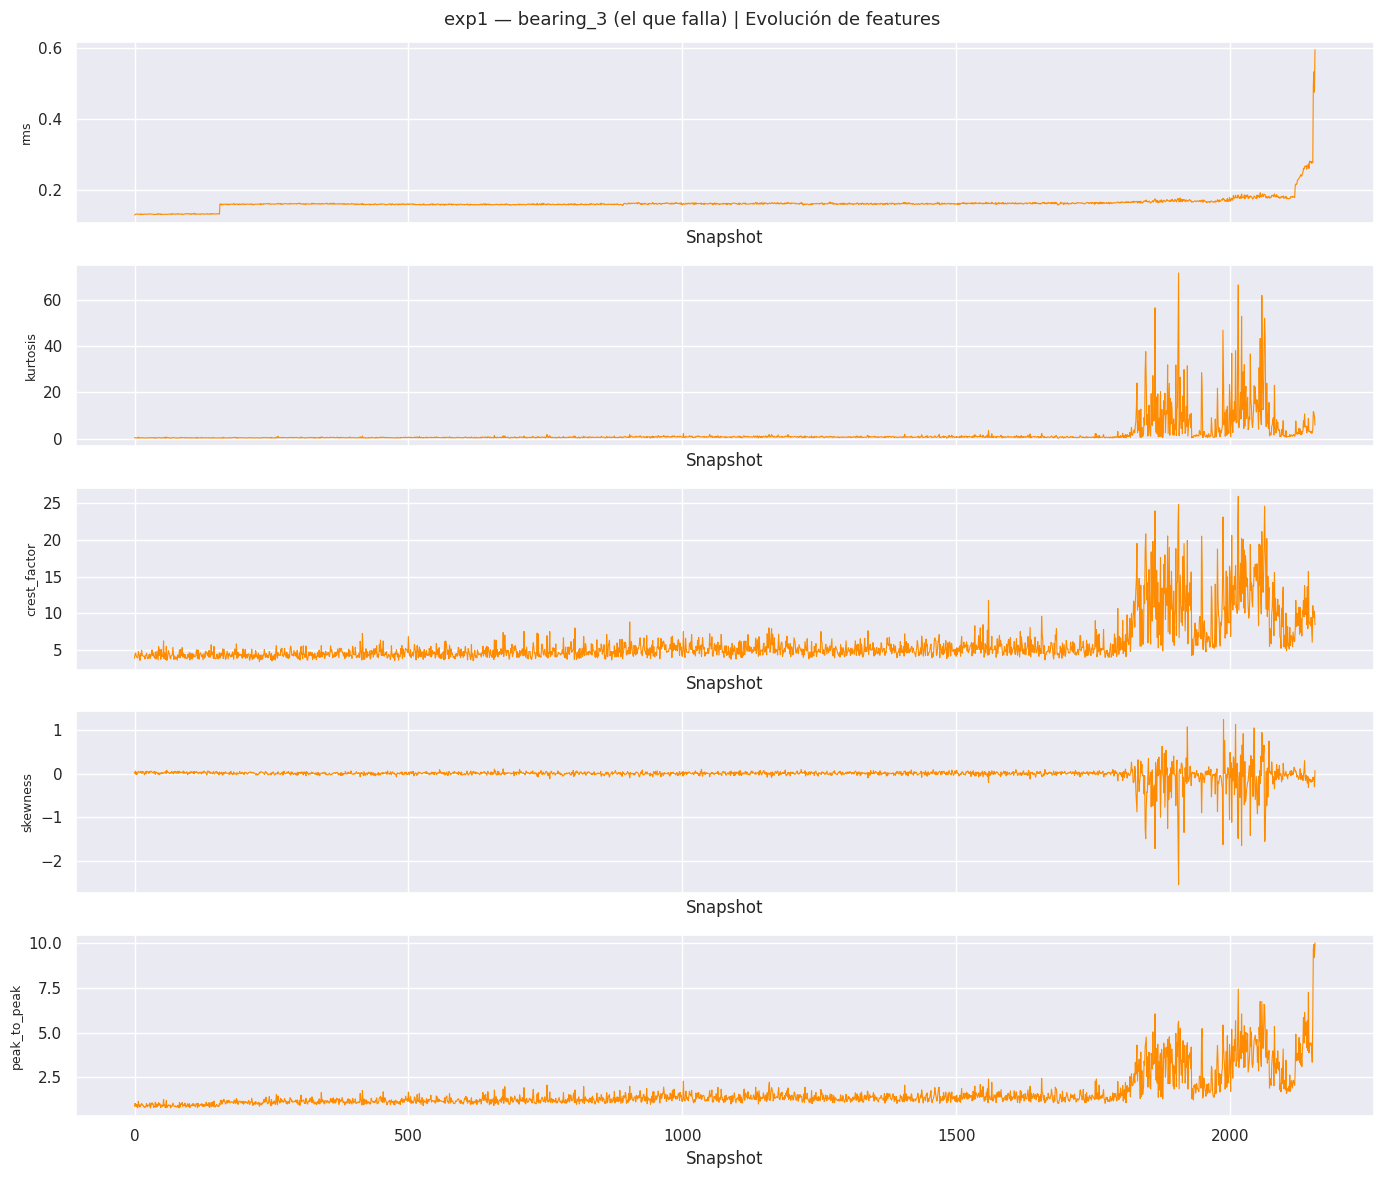

In [4]:
# Ver la evolución de cada feature a lo largo del tiempo para bearing_3 del exp1
# (sabemos que ese es el que falla)
df_exp1 = pd.read_csv(DATA_PROC / "exp1_features.csv")
df_b3   = df_exp1[df_exp1["bearing"] == "bearing_3"].copy()

feature_cols = ["rms", "kurtosis", "crest_factor", "skewness", "peak_to_peak"]

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(14, 12), sharex=True)
fig.suptitle("exp1 — bearing_3 (el que falla) | Evolución de features", fontsize=13)

for ax, feat in zip(axes, feature_cols):
    ax.plot(df_b3["snapshot"], df_b3[feat], linewidth=0.8, color="darkorange")
    ax.set_ylabel(feat, fontsize=9)
    ax.set_xlabel("Snapshot")

plt.tight_layout()
plt.savefig(str(Path.cwd().parent / "outputs" / "features_exp1_bearing3.png"), dpi=120)
plt.show()

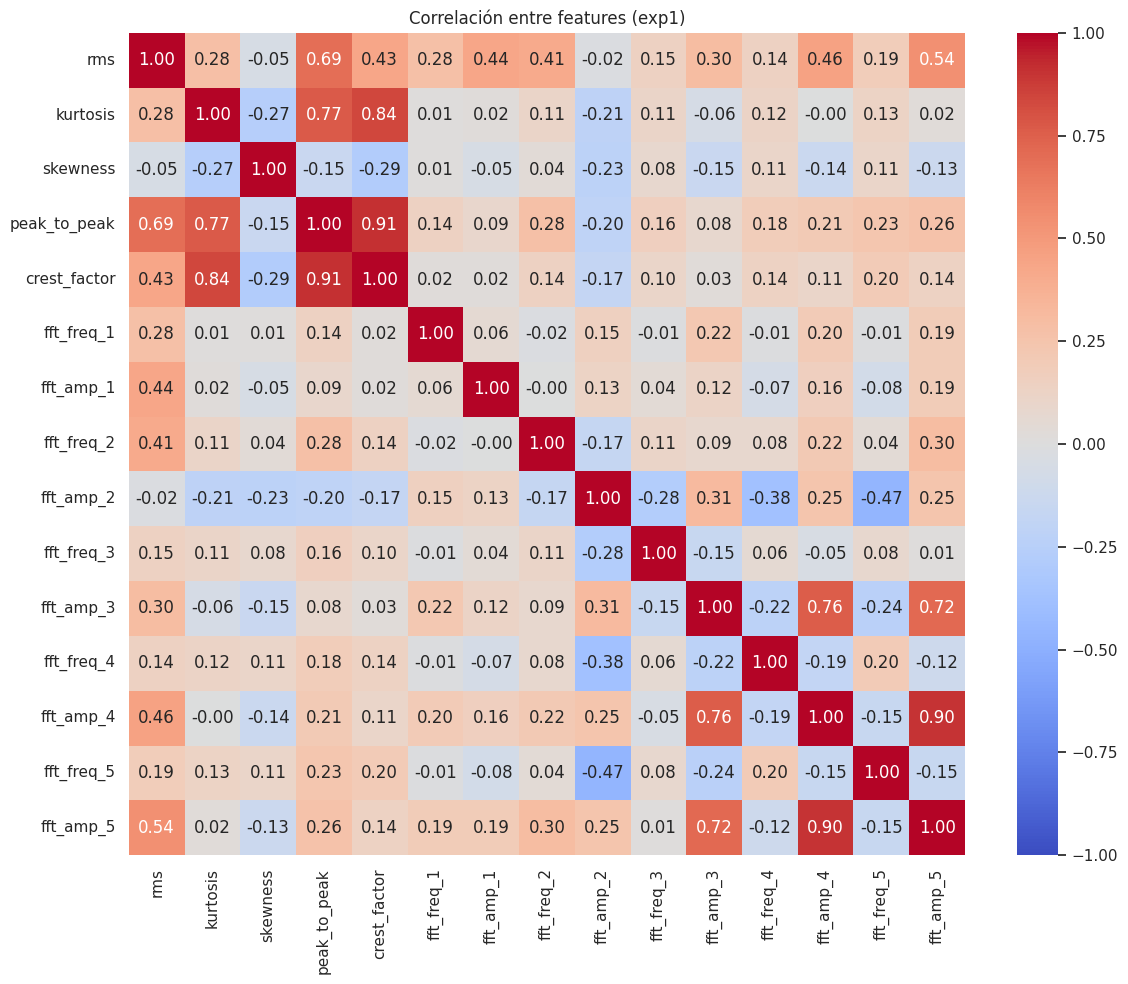

In [5]:
# ¿Las features están muy correlacionadas entre sí? 
# Si dos features dicen exactamente lo mismo, una es redundante
df_exp1 = pd.read_csv(DATA_PROC / "exp1_features.csv")
feat_cols = [c for c in df_exp1.columns if c not in ["experiment", "bearing", "snapshot"]]

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_exp1[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación entre features (exp1)")
plt.tight_layout()
plt.savefig(str(Path.cwd().parent / "outputs" / "feature_correlation.png"), dpi=120)
plt.show()

In [11]:
from src.config import FAILURE_INFO
from src.labeling import compute_rul_labels

df_all = pd.read_csv(DATA_PROC / "all_features.csv")

df_labeled = compute_rul_labels(
    df          = df_all,
    failure_info = FAILURE_INFO,
    burn_in     = 0.7,
    n_std       = 2.0,
)

print(df_labeled[["experiment", "bearing", "snapshot", "rms", "rul", "failure_point", "is_failing"]].head(20))
print(f"\nShape: {df_labeled.shape}")
print(f"\nDistribución RUL:\n{df_labeled['rul'].describe()}")

   experiment    bearing  snapshot       rms  rul  failure_point  is_failing
0        exp1  bearing_1         0  0.124614  1.0             -1       False
1        exp1  bearing_1         1  0.123811  1.0             -1       False
2        exp1  bearing_1         2  0.125246  1.0             -1       False
3        exp1  bearing_1         3  0.125197  1.0             -1       False
4        exp1  bearing_1         4  0.125618  1.0             -1       False
5        exp1  bearing_1         5  0.125988  1.0             -1       False
6        exp1  bearing_1         6  0.125483  1.0             -1       False
7        exp1  bearing_1         7  0.125074  1.0             -1       False
8        exp1  bearing_1         8  0.125396  1.0             -1       False
9        exp1  bearing_1         9  0.124828  1.0             -1       False
10       exp1  bearing_1        10  0.125138  1.0             -1       False
11       exp1  bearing_1        11  0.124817  1.0             -1       False

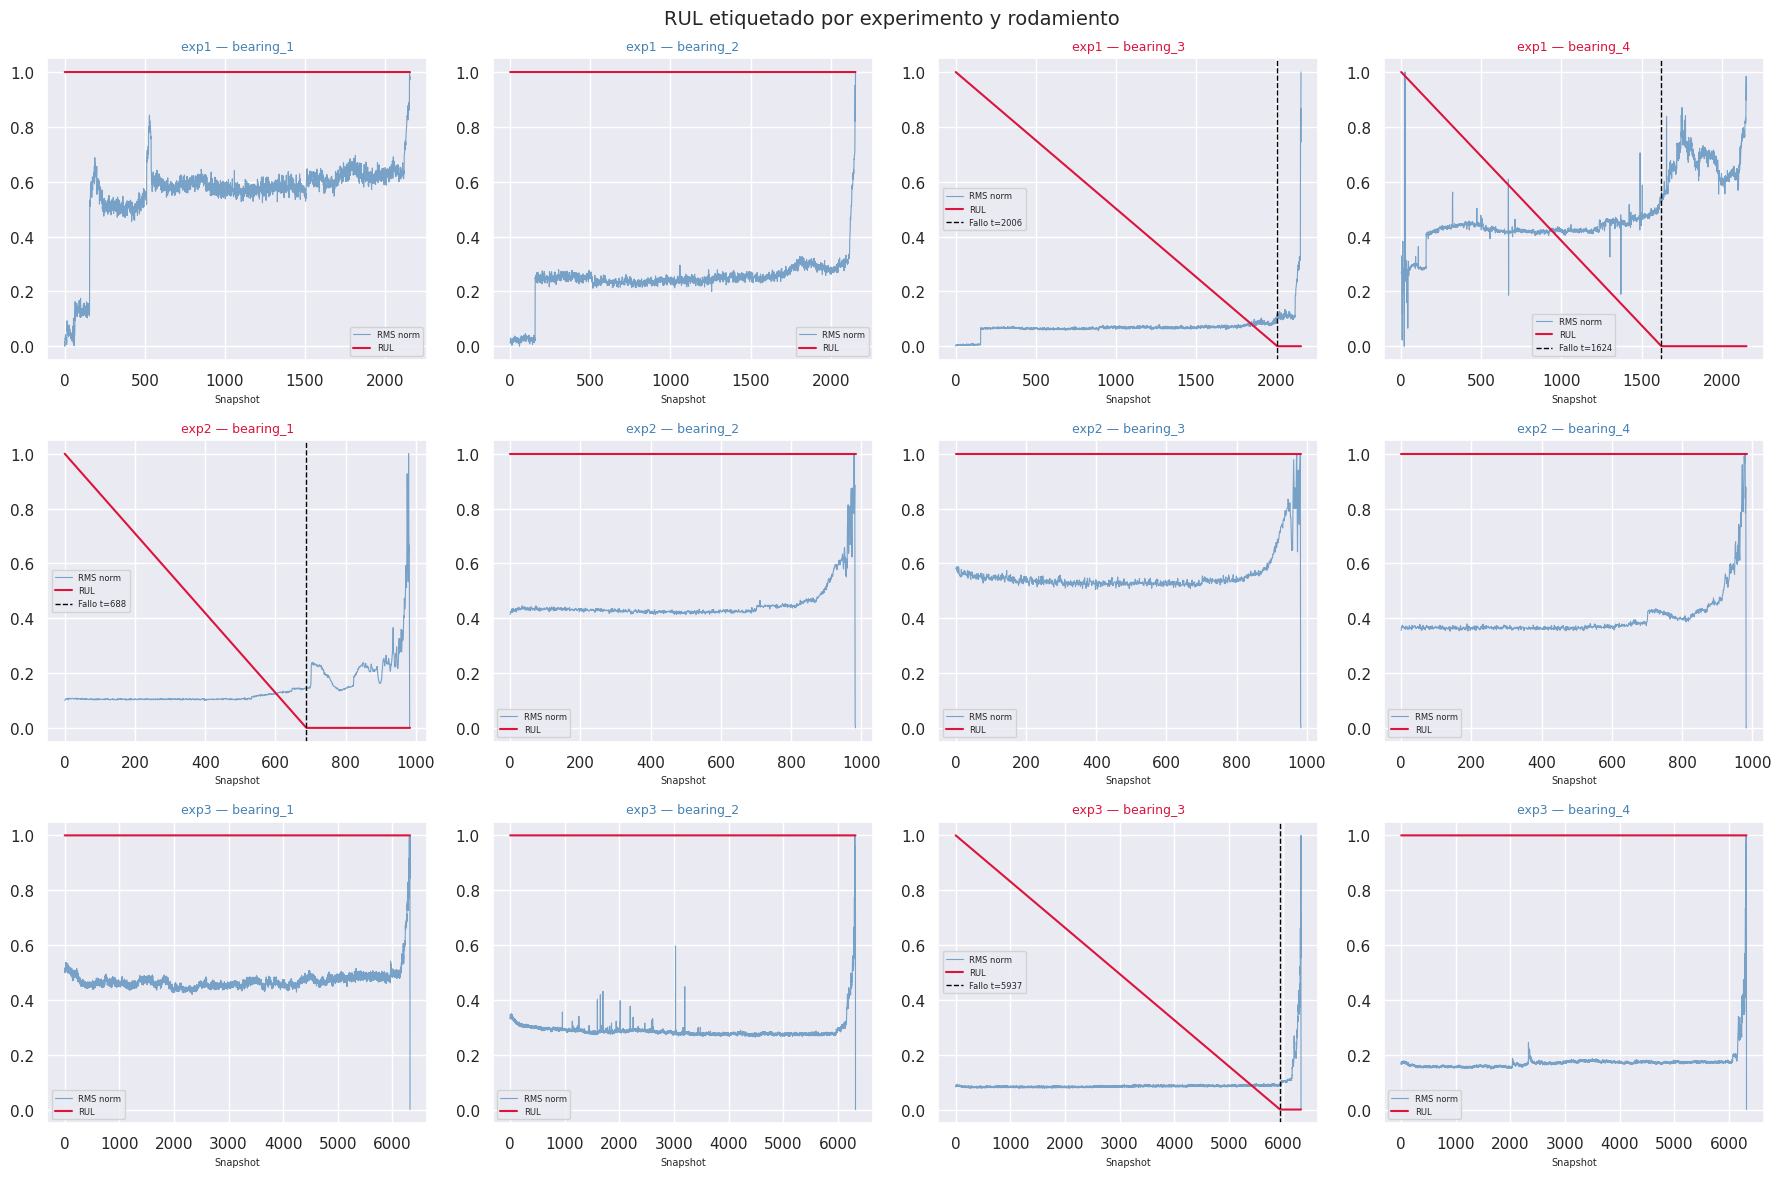

In [12]:
from src.config import FAILURE_INFO, OUTPUTS_DIR

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("RUL etiquetado por experimento y rodamiento", fontsize=14)

for row_idx, exp_name in enumerate(["exp1", "exp2", "exp3"]):
    df_exp = df_labeled[df_labeled["experiment"] == exp_name]
    
    for col_idx, bearing in enumerate(["bearing_1", "bearing_2", "bearing_3", "bearing_4"]):
        ax  = axes[row_idx][col_idx]
        df_b = df_exp[df_exp["bearing"] == bearing]
        
        if df_b.empty:
            ax.set_visible(False)
            continue
        
        is_failing = df_b["is_failing"].iloc[0]
        fp         = df_b["failure_point"].iloc[0]
        
        # RMS normalizado
        rms_norm = (df_b["rms"] - df_b["rms"].min()) / (df_b["rms"].max() - df_b["rms"].min() + 1e-10)
        
        ax.plot(df_b["snapshot"], rms_norm, color="steelblue", linewidth=0.8, label="RMS norm", alpha=0.7)
        ax.plot(df_b["snapshot"], df_b["rul"], color="crimson", linewidth=1.5, label="RUL")
        
        if is_failing and fp > 0:
            ax.axvline(fp, color="black", linestyle="--", linewidth=1, label=f"Fallo t={fp}")
        
        color = "crimson" if is_failing else "steelblue"
        ax.set_title(f"{exp_name} — {bearing}", color=color, fontsize=9)
        ax.set_xlabel("Snapshot", fontsize=7)
        ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "rul_labels.png", dpi=120)
plt.show()

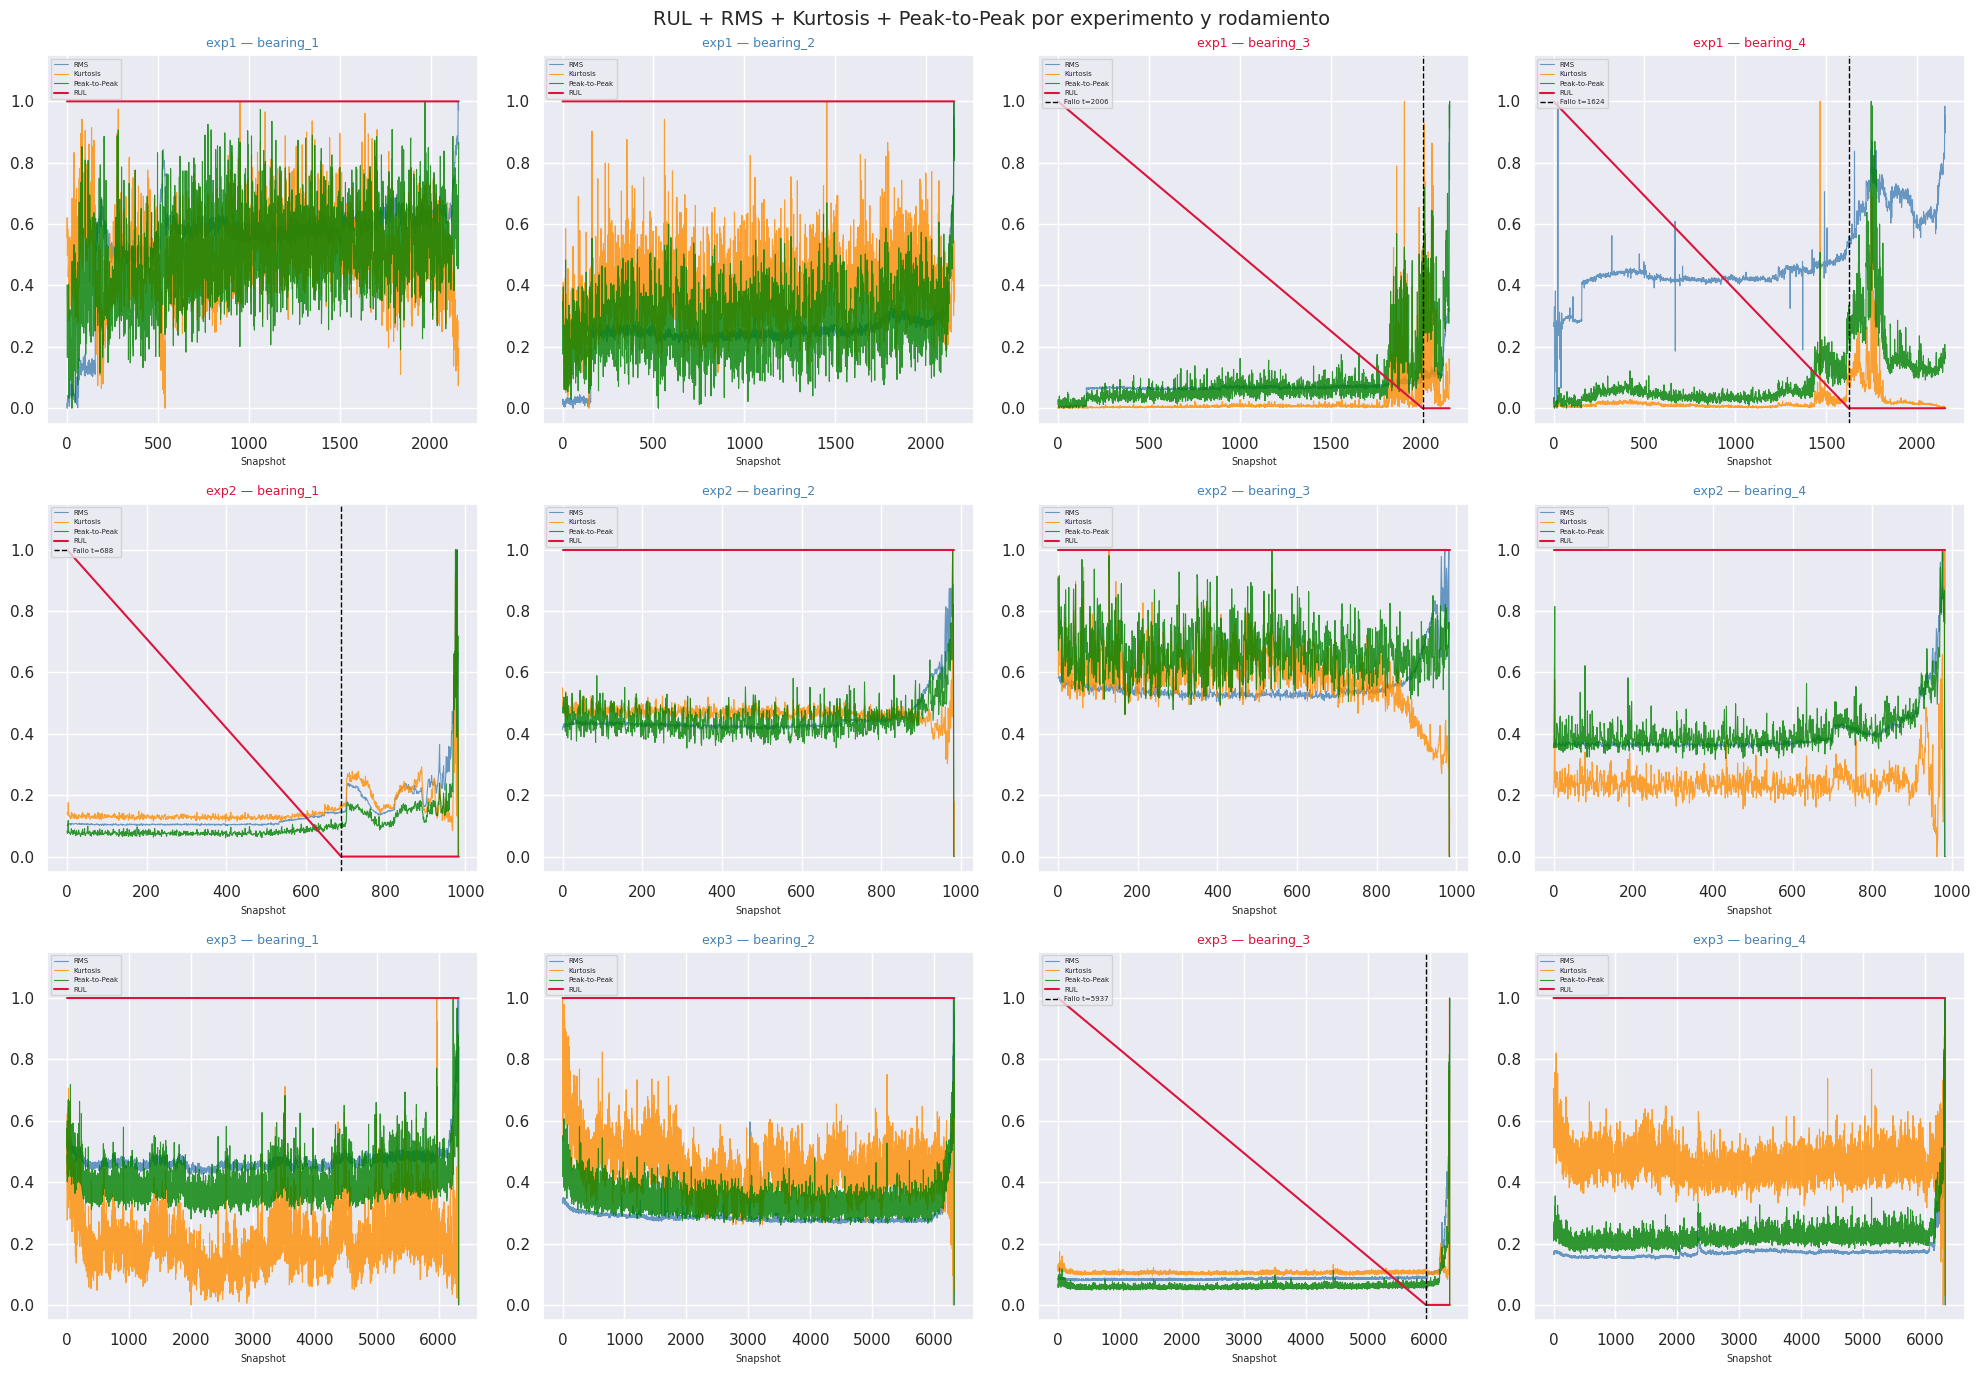

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle("RUL + RMS + Kurtosis + Peak-to-Peak por experimento y rodamiento", fontsize=14)

for row_idx, exp_name in enumerate(["exp1", "exp2", "exp3"]):
    df_exp = df_labeled[df_labeled["experiment"] == exp_name]
    
    for col_idx, bearing in enumerate(["bearing_1", "bearing_2", "bearing_3", "bearing_4"]):
        ax   = axes[row_idx][col_idx]
        df_b = df_exp[df_exp["bearing"] == bearing]
        
        if df_b.empty:
            ax.set_visible(False)
            continue
        
        is_failing = df_b["is_failing"].iloc[0]
        fp         = df_b["failure_point"].iloc[0]
        x          = df_b["snapshot"].values

        def normalize(s):
            mn, mx = s.min(), s.max()
            return (s - mn) / (mx - mn + 1e-10)

        rms_n  = normalize(df_b["rms"].values)
        kurt_n = normalize(df_b["kurtosis"].values)
        p2p_n  = normalize(df_b["peak_to_peak"].values)
        rul    = df_b["rul"].values

        ax.plot(x, rms_n,  color="steelblue",  linewidth=0.8, alpha=0.8, label="RMS")
        ax.plot(x, kurt_n, color="darkorange",  linewidth=0.8, alpha=0.8, label="Kurtosis")
        ax.plot(x, p2p_n,  color="green",       linewidth=0.8, alpha=0.8, label="Peak-to-Peak")
        ax.plot(x, rul,    color="crimson",      linewidth=1.5,            label="RUL")

        if is_failing and fp > 0:
            ax.axvline(fp, color="black", linestyle="--", linewidth=1, label=f"Fallo t={fp}")

        title_color = "crimson" if is_failing else "steelblue"
        ax.set_title(f"{exp_name} — {bearing}", color=title_color, fontsize=9)
        ax.set_xlabel("Snapshot", fontsize=7)
        ax.set_ylim(-0.05, 1.15)
        ax.legend(fontsize=5, loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "rul_labels_multifeature.png", dpi=120)
plt.show()

In [14]:
out_path = DATA_PROC / "all_features_labeled.csv"
df_labeled.to_csv(out_path, index=False)
print(f"Guardado: {out_path}")
print(f"Shape: {df_labeled.shape}")
print(f"\nColumnas: {list(df_labeled.columns)}")

Guardado: /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/processed/all_features_labeled.csv
Shape: (37856, 21)

Columnas: ['experiment', 'bearing', 'snapshot', 'rms', 'kurtosis', 'skewness', 'peak_to_peak', 'crest_factor', 'fft_freq_1', 'fft_amp_1', 'fft_freq_2', 'fft_amp_2', 'fft_freq_3', 'fft_amp_3', 'fft_freq_4', 'fft_amp_4', 'fft_freq_5', 'fft_amp_5', 'rul', 'failure_point', 'is_failing']
